<a href="https://colab.research.google.com/github/20020608/Notepad/blob/main/clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.cluster import KMeans

In [11]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv('Categorical.csv')
df.head()

Saving Categorical.csv to Categorical.csv


,name,Longitude,Latitude,continent
0,Aruba,-69.982677,12.520880,North America
1,Afghanistan,66.004734,33.835231,Asia
2,Angola,17.537368,-12.293361,Africa
3,Anguilla,-63.064989,18.223959,North America
4,Albania,20.049834,41.142450,Europe


In [13]:
data=df.copy()
# data=data.drop(['Unnamed:0'], axis=1) # This column does not exist in your DataFrame

In [14]:
data_mapped=data.copy()
data_mapped['continent'] = data_mapped['continent'].map({'North America':0,'Europe':1,'Asia':2,'Africa':3,'South America':4, 'Oceania':5,'Seven seas (open ocean)':6, 'Antarctica':7})
data_mapped


,name,Longitude,Latitude,continent
0,Aruba,-69.982677,12.520880,0
1,Afghanistan,66.004734,33.835231,2
2,Angola,17.537368,-12.293361,3
3,Anguilla,-63.064989,18.223959,0
4,Albania,20.049834,41.142450,1
...,...,...,...,...
236,Samoa,-172.164851,-13.753243,5
237,Yemen,47.586762,15.909280,2
238,South Africa,25.083901,-29.000341,3
239,Zambia,27.774759,-13.458242,3


In [17]:
x = data_mapped.iloc[:,3:4]

In [19]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4)
kmeans.fit(x)
print(x.head())

   continent
0          0
1          2
2          3
3          0
4          1


In [22]:
identified_clusters = kmeans.fit_predict(x)
identified_clusters

array([1, 3, 2, 1, 1, 1, 1, 3, 0, 3, 0, 0, 0, 0, 1, 0, 1, 3, 2, 1, 2, 2,
       3, 1, 3, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 3, 3, 2, 2, 1, 0, 3, 2, 2,
       2, 2, 0, 0, 2, 2, 1, 1, 1, 1, 3, 3, 1, 1, 2, 1, 1, 1, 2, 0, 2, 2,
       1, 1, 2, 1, 0, 0, 1, 1, 0, 2, 1, 3, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1,
       0, 0, 3, 0, 1, 1, 1, 1, 3, 1, 3, 3, 0, 1, 3, 3, 1, 3, 1, 1, 1, 3,
       3, 3, 3, 2, 3, 3, 0, 1, 3, 1, 3, 3, 3, 2, 2, 1, 1, 3, 2, 1, 1, 1,
       3, 1, 2, 1, 1, 2, 0, 1, 0, 1, 2, 1, 3, 1, 3, 0, 2, 2, 1, 0, 2, 3,
       2, 0, 2, 0, 2, 1, 0, 1, 1, 3, 0, 0, 3, 3, 1, 0, 0, 3, 0, 0, 1, 1,
       3, 1, 0, 3, 0, 3, 1, 1, 2, 2, 3, 2, 2, 2, 3, 0, 0, 0, 2, 1, 1, 2,
       2, 1, 1, 2, 0, 1, 1, 1, 2, 1, 0, 3, 1, 2, 2, 3, 3, 3, 3, 0, 1, 2,
       3, 3, 2, 2, 1, 0, 1, 3, 1, 1, 0, 1, 1, 3, 0, 0, 0, 3, 2, 2, 2],
      dtype=int32)

In [23]:
data_with_clusters = data_mapped.copy()
data_with_clusters['Cluster'] = identified_clusters
data_with_clusters

,name,Longitude,Latitude,continent,Cluster
0,Aruba,-69.982677,12.520880,0,1
1,Afghanistan,66.004734,33.835231,2,3
2,Angola,17.537368,-12.293361,3,2
3,Anguilla,-63.064989,18.223959,0,1
4,Albania,20.049834,41.142450,1,1
...,...,...,...,...,...
236,Samoa,-172.164851,-13.753243,5,0
237,Yemen,47.586762,15.909280,2,3
238,South Africa,25.083901,-29.000341,3,2
239,Zambia,27.774759,-13.458242,3,2


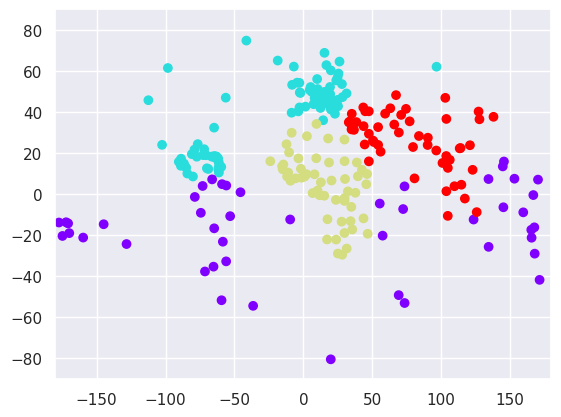

In [24]:
plt.scatter(data['Longitude'], data['Latitude'], c=data_with_clusters['Cluster'], cmap = 'rainbow')
plt.xlim(-180,180)
plt.ylim(-90, 90)
plt.show()